In [1]:
import pandas as pd
import numpy as np

# Load your datasets (assuming they are already in memory)
# climate_df: [County, Date, Temp_max, Temp_min, Rainfall, Humidity, Soil_pH]
# crop_req: [Crop, Min_Temp, Max_Temp, Min_Rain, Max_Rain, Min_pH, Max_pH]
climate_df = pd.read_csv('datasets/raw_climate_data.csv')
crop_req = pd.read_csv('datasets/crop_requirements/crop_requirements.csv')

In [2]:
climate_df["Temp_max"] = climate_df["T2M_MAX"]
climate_df["Temp_min"] = climate_df["T2M_MIN"]
climate_df["Rainfall"] = climate_df["PRECTOTCORR"]
climate_df["Humidity"] = climate_df["RH2M"]
climate_df["Soil_pH"] = climate_df["Soil_pH_0_5cm"]

In [3]:
import pandas as pd

# 1. Ensure Date is a datetime object
climate_df['Date'] = pd.to_datetime(climate_df['Date'])
climate_df = climate_df.sort_values(['County', 'Date'])

# 2. Convert Daily Rain to "Annualized Rain" (Moving Year Total)
# We sum the rain over the last 365 days for that specific county
climate_df['Rainfall_Annualized'] = climate_df.groupby('County')['Rainfall'].transform(
    lambda x: x.rolling(window=365, min_periods=1).sum()
)

# 3. Handle Temperature (Daily is fine, but we can smooth it)
# Crop requirements are usually based on mean monthly temperatures
climate_df['Temp_Avg'] = (climate_df['Temp_max'] + climate_df['Temp_min']) / 2

# 4. Handle Humidity and pH
# These are usually stable, so a 30-day moving average removes daily "noise"
climate_df['Humidity_Smooth'] = climate_df.groupby('County')['Humidity'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

# We keep pH as is or take a mean if it varies daily
climate_df['Soil_pH_Smooth'] = climate_df.groupby('County')['Soil_pH'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

In [4]:
climate_df.tail()

,Date,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,County,Latitude,Longitude,Soil_pH_0_5cm,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Rainfall_Annualized,Temp_Avg,Humidity_Smooth,Soil_pH_Smooth
131491,2024-12-27,28.02,14.94,0.16,63.73,west pokot,1.621,35.23,6.2,28.02,14.94,0.16,63.73,6.2,1841.42,21.480,68.620333,6.2
131492,2024-12-28,27.97,14.05,0.01,58.25,west pokot,1.621,35.23,6.2,27.97,14.05,0.01,58.25,6.2,1840.26,21.010,67.642333,6.2
131493,2024-12-29,28.23,12.99,0.00,52.11,west pokot,1.621,35.23,6.2,28.23,12.99,0.00,52.11,6.2,1839.92,20.610,66.545000,6.2
131494,2024-12-30,28.35,13.53,0.01,52.27,west pokot,1.621,35.23,6.2,28.35,13.53,0.01,52.27,6.2,1837.91,20.940,65.676667,6.2
131495,2024-12-31,27.97,14.48,0.34,58.44,west pokot,1.621,35.23,6.2,27.97,14.48,0.34,58.44,6.2,1829.52,21.225,65.119000,6.2


In [5]:
crop_req

,Crop,Min_Temp,Max_Temp,Min_Rain,Max_Rain,Min_pH,Max_pH
0,Apples,10,25,800,1200,6.0,7.0
1,Arrow Root,16,30,1000,2000,5.5,6.5
2,Avocado,15,28,1000,2000,5.0,7.0
3,Banana (Cooking),15,30,1000,2500,5.5,7.0
4,Banana (Plantain),18,35,1000,2500,5.5,7.0
...,...,...,...,...,...,...,...
58,Water Melon,20,35,400,600,6.0,6.8
59,Wheat,-3,23,500,1200,5.5,6.5
60,White Irish Potatoes,10,25,850,1400,5.0,6.5
61,White Sorghum,20,35,400,1000,5.0,7.5


In [7]:
suitability_records = []

# To make it efficient, we loop through each crop in your requirements
for _, row in crop_req.iterrows():
    crop_name = row['Crop']
    
    # Check suitability conditions across the entire climate history
    # We use (Temp_max + Temp_min) / 2 to get the mean temperature for the day
    avg_temp = (climate_df['Temp_max'] + climate_df['Temp_min']) / 2
    
    # Use the NEW annualized and smoothed columns
    is_suitable = (
        (climate_df['Temp_Avg'] >= row['Min_Temp']) & (climate_df['Temp_Avg'] <= row['Max_Temp']) &
        (climate_df['Rainfall_Annualized'] >= row['Min_Rain']) & (climate_df['Rainfall_Annualized'] <= row['Max_Rain']) &
        (climate_df['Soil_pH_Smooth'] >= row['Min_pH']) & (climate_df['Soil_pH_Smooth'] <= row['Max_pH'])
    ).astype(int)
    
    # Create temporary dataframe for this specific crop
    temp_suit_df = climate_df.copy()
    temp_suit_df['Crop'] = crop_name
    temp_suit_df['Suitability'] = is_suitable
    
    suitability_records.append(temp_suit_df)

# Combine everything into one giant suitability dataset
suit_master_df = pd.concat(suitability_records, ignore_index=True)

In [8]:
suit_master_df

,Date,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,County,Latitude,Longitude,Soil_pH_0_5cm,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Rainfall_Annualized,Temp_Avg,Humidity_Smooth,Soil_pH_Smooth,Crop,Suitability
0,2010-01-01,24.21,17.45,18.02,79.94,baringo,0.4667,35.9667,6.8,24.21,17.45,18.02,79.94,6.8,18.02,20.830,79.940000,6.8,Apples,0
1,2010-01-02,24.87,15.85,17.44,77.86,baringo,0.4667,35.9667,6.8,24.87,15.85,17.44,77.86,6.8,35.46,20.360,78.900000,6.8,Apples,0
2,2010-01-03,27.28,16.71,0.59,71.66,baringo,0.4667,35.9667,6.8,27.28,16.71,0.59,71.66,6.8,36.05,21.995,76.486667,6.8,Apples,0
3,2010-01-04,25.98,16.00,10.17,71.18,baringo,0.4667,35.9667,6.8,25.98,16.00,10.17,71.18,6.8,46.22,20.990,75.160000,6.8,Apples,0
4,2010-01-05,27.36,14.57,7.17,66.15,baringo,0.4667,35.9667,6.8,27.36,14.57,7.17,66.15,6.8,53.39,20.965,73.358000,6.8,Apples,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16223314,2024-12-27,28.02,14.94,0.16,63.73,west pokot,1.6210,35.2300,6.2,28.02,14.94,0.16,63.73,6.2,1841.42,21.480,68.620333,6.2,Yam,1
16223315,2024-12-28,27.97,14.05,0.01,58.25,west pokot,1.6210,35.2300,6.2,27.97,14.05,0.01,58.25,6.2,1840.26,21.010,67.642333,6.2,Yam,1
16223316,2024-12-29,28.23,12.99,0.00,52.11,west pokot,1.6210,35.2300,6.2,28.23,12.99,0.00,52.11,6.2,1839.92,20.610,66.545000,6.2,Yam,1
16223317,2024-12-30,28.35,13.53,0.01,52.27,west pokot,1.6210,35.2300,6.2,28.35,13.53,0.01,52.27,6.2,1837.91,20.940,65.676667,6.2,Yam,1


In [9]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode 'County' and 'Crop' as they are categorical
county_le = LabelEncoder()
crop_le = LabelEncoder()

suit_master_df['County_Enc'] = county_le.fit_transform(suit_master_df['County'])
suit_master_df['Crop_Enc'] = crop_le.fit_transform(suit_master_df['Crop'])

# Define Features (Environment + The Crop we are testing)
X = suit_master_df[['County_Enc', 'Crop_Enc', 'Temp_max', 'Temp_min', 'Rainfall', 'Humidity', 'Soil_pH']]
y = suit_master_df['Suitability']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize and train XGBoost Binary Classifier
suit_model = xgb.XGBClassifier(
    objective='binary:logistic', 
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

suit_model.fit(X_train, y_train)
print("Suitability Model Training Complete!")

Suitability Model Training Complete!


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the test set
y_pred = suit_model.predict(X_test)
y_pred_proba = suit_model.predict_proba(X_test)[:, 1] # Probability for the 'Suitable' class

# 2. Calculate Percentage Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Suitability Accuracy: {accuracy * 100:.2f}%")

# 3. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for both Suitable (1) and Unsuitable (0)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4. AUC-ROC Score
# Measures how well the model distinguishes between suitable and unsuitable crops
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc:.4f}")

Overall Suitability Accuracy: 81.70%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89   2444538
           1       0.72      0.42      0.53    800126

    accuracy                           0.82   3244664
   macro avg       0.78      0.68      0.71   3244664
weighted avg       0.81      0.82      0.80   3244664

AUC-ROC Score: 0.8850


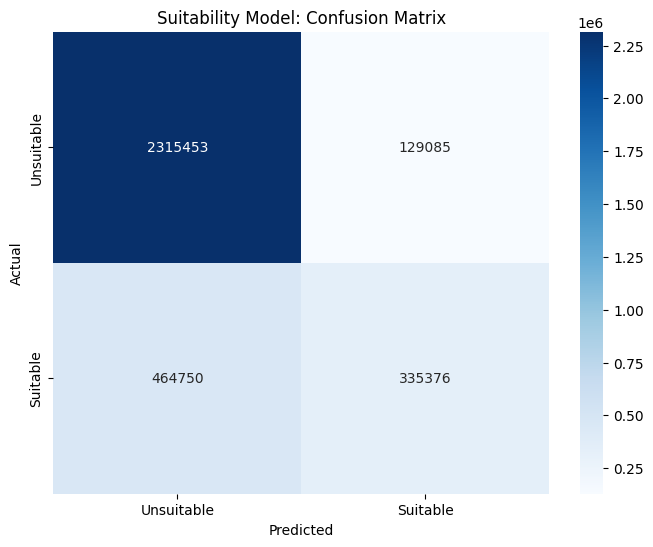

In [11]:
# 5. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unsuitable', 'Suitable'], 
            yticklabels=['Unsuitable', 'Suitable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Suitability Model: Confusion Matrix')
plt.show()

In [17]:
def get_suitability_recommendations(county, temp_max, temp_min, rainfall, humidity, soil_ph):
    # 1. Get a list of all unique crops from your encoder
    all_crops = crop_le.classes_
    county_enc = county_le.transform([county])[0]
    
    recommendations = []

    # 2. Loop through every crop and ask the model: "Is this suitable?"
    for crop_name in all_crops:
        crop_enc = crop_le.transform([crop_name])[0]
        
        # Prepare the input features for the model
        # Order: ['County_Enc', 'Crop_Enc', 'Temp_max', 'Temp_min', 'Rainfall', 'Humidity', 'Soil_pH']
        features = pd.DataFrame([[
            county_enc, crop_enc, temp_max, temp_min, rainfall, humidity, soil_ph
        ]], columns=X.columns)
        
        # Get prediction and probability
        is_suitable = suit_model.predict(features)[0]
        probability = suit_model.predict_proba(features)[0][1] # Prob of being 'Suitable'
        
        if is_suitable == 1:
            recommendations.append({
                "Crop": crop_name,
                "Match_Score": round(probability * 100, 2)
            })

    # 3. Sort by the highest Match Score
    return sorted(recommendations, key=lambda x: x['Match_Score'], reverse=True)

# --- TEST IT ---
test_county = "machakos" 
# results = get_suitability_recommendations(test_county, 31, 24, 600, 75, 6.5)
# results = get_suitability_recommendations(
#     county=test_county, 
#     temp_max=28, 
#     temp_min=18, 
#     rainfall=500,  # Low annualized rainfall
#     humidity=50, 
#     soil_ph=7.0    # Often more alkaline/neutral in drylands
# )

results = get_suitability_recommendations(
    county="uasin gishu", 
    temp_max=24, 
    temp_min=12, 
    rainfall=1100,  # Annualized total for a high-potential zone
    humidity=65, 
    soil_ph=6.0
)


print(f"\n--- Suitable Crops for {test_county.title()} ---")
for res in results:
    print(f"✅ {res['Crop']}: {res['Match_Score']}% match")


--- Suitable Crops for Machakos ---
✅ Banana (Cooking): 71.77999877929688% match
✅ Avocado: 52.0% match


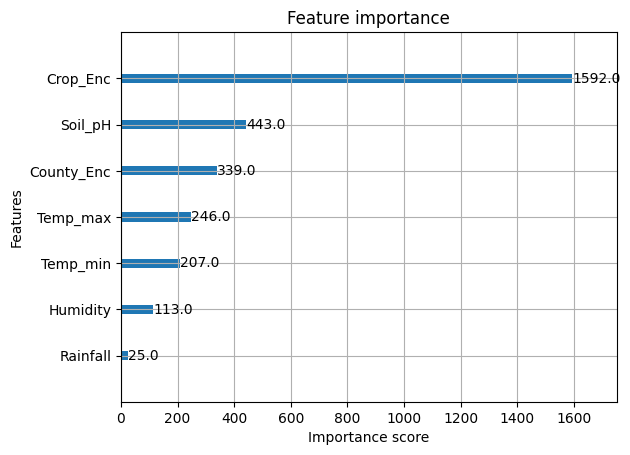

In [14]:
import matplotlib.pyplot as plt
xgb.plot_importance(suit_model)
plt.show()